# Attentive Neural Process Emulator for CAMELS Thermodynamic Profiles

## A Comprehensive Tutorial

**Conference Tutorial — April 2026**

---

This notebook provides a self-contained walkthrough of the Attentive Neural Process (ANP) emulator for cosmological hydrodynamic simulation profiles from the CAMELS project. We cover:

1. **Motivation** — Why emulate CAMELS profiles?
2. **Mathematical Foundations** — Neural Processes, the ELBO, and the ANP architecture
3. **Data Representation** — How CAMELS profiles map to ANP inputs/outputs
4. **Model Architecture** — Encoder paths, latent variables, and the decoder
5. **Training Pipeline** — Mean model, residual learning, loss functions, and regularization
6. **Inference API** — Loading a checkpoint and making predictions in 3 lines of code
7. **Worked Example** — Predicting gas profiles and visualizing uncertainty
8. **Diagnostics** — Coverage, calibration, and residual analysis

### Requirements
```
torch >= 2.0
numpy
matplotlib
scipy
```

---
# 1. Motivation

The [CAMELS](https://camels.readthedocs.io/) project provides thousands of cosmological hydrodynamic simulations spanning a wide range of cosmological and astrophysical parameters. Each simulation produces **radial profiles** of gas properties (density, temperature, pressure, metallicity, velocity, etc.) around dark-matter halos.

These profiles encode the thermodynamic state of the intracluster medium (ICM) and circumgalactic medium (CGM), which are critical for:
- **Galaxy cluster cosmology** (Sunyaev-Zel'dovich effect, X-ray scaling relations)
- **Understanding baryonic feedback** (AGN, supernovae, stellar winds)
- **Forward-modeling observables** for upcoming surveys (CMB-S4, eROSITA, Rubin)

**The problem:** Running full hydrodynamic simulations is extremely expensive ($\sim 10^5$ CPU-hours per box). We need a fast, accurate **emulator** that, given cosmological/astrophysical parameters $(\theta)$, halo mass $(M_{500c})$, and radius $(r/R_{500})$, predicts the full thermodynamic profile *with calibrated uncertainties*.

**Our solution:** An Attentive Neural Process that:
- Predicts *distributions* over profiles, not just point estimates
- Decomposes uncertainty into **aleatoric** (intrinsic halo-to-halo scatter) and **epistemic** (model uncertainty)
- Handles multiple output channels simultaneously (temperature, pressure, gas density, ...)
- Generalizes across halo masses, radii, and cosmological parameters

---
# 2. Mathematical Foundations

## 2.1 Neural Processes (NP)

A **Neural Process** (Garnelo et al. 2018) defines a distribution over functions. Given a set of **context points** $\mathcal{C} = \{(x_c^{(i)}, y_c^{(i)})\}_{i=1}^{N_C}$ and **target locations** $\{x_t^{(j)}\}_{j=1}^{N_T}$, the NP predicts a distribution $p(y_t \mid x_t, \mathcal{C})$ over target outputs.

The core ingredients:
1. An **encoder** that summarizes the context set into a finite-dimensional representation
2. A **latent variable** $z$ that captures global function-level uncertainty
3. A **decoder** that maps $(x_t, z, \text{representation})$ to a predictive distribution

## 2.2 The Latent Variable Model

The generative model factorizes as:

$$p(y_T \mid x_T, \mathcal{C}) = \int p(y_T \mid x_T, z, r) \, p(z \mid \mathcal{C}) \, dz$$

where:
- $z \sim \mathcal{N}(\mu_z(\mathcal{C}),\, \sigma_z^2(\mathcal{C}))$ is the **latent variable** encoding global uncertainty
- $r = \text{CrossAttn}(\mathcal{C}, x_T)$ is the **deterministic representation** from the attention path
- $p(y_T \mid x_T, z, r) = \mathcal{N}(\mu_\text{dec},\, \sigma_\text{dec}^2)$ is the decoder output

## 2.3 Training: The ELBO

We train by maximizing the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L} = \underbrace{\mathbb{E}_{q(z|\mathcal{T})}\left[\sum_{j} \log p(y_t^{(j)} \mid x_t^{(j)}, z, r)\right]}_{\text{Reconstruction}} - \underbrace{\beta \cdot D_{\text{KL}}\left[q(z \mid \mathcal{T}) \,\|\, q(z \mid \mathcal{C})\right]}_{\text{KL Regularization}}$$

where:
- $\mathcal{T} = \mathcal{C} \cup \mathcal{T}_{\text{target}}$ is the full (context + target) set — the posterior
- $q(z \mid \mathcal{C})$ is the prior (context-only encoding) — what we have at test time
- $\beta$ is a KL warmup coefficient (annealed from 0 → 1 during training)

The **reconstruction term** encourages accurate predictions. The **KL term** regularizes the latent space and ensures the context-only prior $q(z|\mathcal{C})$ stays close to the full-data posterior $q(z|\mathcal{T})$.

## 2.4 Key Insight: The Attentive NP

The original NP uses a simple mean-aggregation of context embeddings, losing ordering information. The **Attentive NP** (Kim et al. 2019) adds a **cross-attention** mechanism:

$$r_j = \text{MultiHeadAttn}\!\left(Q=\phi(x_t^{(j)}),\; K=\phi(x_c),\; V=\psi(x_c, y_c)\right)$$

This allows each target point to selectively attend to the most relevant context points, dramatically improving prediction quality for structured functions like radial profiles.

## 2.5 Decoder Likelihood

The decoder outputs parameters of a **Gaussian** (or optionally **Student-$t$**) distribution:

$$p(y \mid x, z, r) = \mathcal{N}\!\left(\mu_\theta(x, z, r),\; \sigma_\theta^2(x, z, r)\right)$$

Student-$t$ with $\nu$ degrees of freedom provides heavier tails:

$$p(y \mid x, z, r) = t_\nu\!\left(\mu_\theta(x, z, r),\; \sigma_\theta^2(x, z, r)\right)$$

## 2.6 Uncertainty Decomposition

At inference, we draw $S$ samples $z^{(s)} \sim q(z \mid \mathcal{C})$ and compute:

| Component | Formula | Interpretation |
|-----------|---------|----------------|
| **Predictive mean** | $\hat{\mu} = \frac{1}{S}\sum_s \mu^{(s)}$ | Best estimate |
| **Aleatoric variance** | $\sigma^2_\text{alea} = \frac{1}{S}\sum_s (\sigma^{(s)})^2$ | Irreducible scatter |
| **Epistemic variance** | $\sigma^2_\text{epi} = \text{Var}_s[\mu^{(s)}]$ | Model uncertainty |
| **Total variance** | $\sigma^2_\text{total} = \sigma^2_\text{alea} + \sigma^2_\text{epi}$ | Law of total variance |

---
# 3. Data Representation

## 3.1 Input Space

Each data point $(x, y)$ represents a measurement at a specific radial bin of a specific halo in a specific simulation. The input vector $x$ is:

$$x = [\log_{10} M_{500c},\; \log_{10}(r/R_{500}),\; \theta_1, \theta_2, \ldots, \theta_{35}]$$

where:
- $\log_{10} M_{500c}$ — halo mass (in solar masses) within $R_{500}$
- $\log_{10}(r/R_{500})$ — scaled radial coordinate (self-similar scaling)
- $\theta_{1..35}$ — the 35 CAMELS feedback and cosmological parameters:
  - 2 cosmological: $\Omega_m$, $\sigma_8$
  - 4 astrophysical (SN/AGN feedback strengths)
  - 29 additional IllustrisTNG sub-grid parameters (SB35 = "Sobol 35-parameter")

## 3.2 Output Space

The output $y$ is the profile value at that radial bin. In **all_profiles** mode, $y$ is a multi-channel vector:

$$y = [T(r),\; P(r),\; \rho_\text{gas}(r)]$$

**Log-space modeling:** Positive-definite quantities (density, temperature, pressure) are modeled in $\log_{10}$ space for numerical stability and to enforce physical positivity. At inference time, predictions are automatically converted back to physical units via the delta method:

$$\sigma_\text{phys} = \ln(10) \cdot 10^{\mu_{\log_{10}}} \cdot \sigma_{\log_{10}}$$

## 3.3 Data Organization

CAMELS data is organized as **run families** — each simulation run produces profiles at one or more redshift snapshots:

```
RunFamily(run_id=42)
  ├── Snapshot(z=0.0):  [n_halos × n_radial_bins × (x_dim, y_dim)]
  ├── Snapshot(z=0.5):  [...]
  ├── Snapshot(z=1.0):  [...]
  └── Snapshot(z=2.0):  [...]
```

The train/validation/test split is done **at the family level** to prevent information leakage between snapshots of the same simulation.

---
# 4. Model Architecture

## 4.1 Overview

Our `StrongANP` model consists of four major components:

```
                    Context (xc, yc)               Target (xt)
                         │                              │
              ┌──────────┴──────────┐                   │
              ▼                     ▼                   │
     ┌─────────────────┐   ┌──────────────────┐        │
     │ Latent Encoder  │   │ Deterministic Path│        │
     │ (Self-Attention │   │ (Self-Attention + │        │
     │  → Pool → μ,σ) │   │  Cross-Attention) │        │
     └────────┬────────┘   └────────┬─────────┘        │
              │                     │                   │
         z ~ N(μ,σ²)              r_j                  │
              │                     │                   │
              └─────────┬───────────┘                   │
                        ▼                               │
               ┌────────────────┐                       │
               │    Decoder     │◄──────────────────────┘
               │ (MLP + FiLM   │
               │  conditioning) │
               └───────┬────────┘
                       │
                  (μ_y, σ_y)
```

## 4.2 Fourier Embedding of Radius

The radial coordinate $\log_{10}(r/R_{500})$ is enriched with **random Fourier features** to help the model capture high-frequency variations in the profile shape:

$$\text{FourierEmbed}(r) = [\sin(B \cdot r),\; \cos(B \cdot r)]$$

where $B \in \mathbb{R}^{1 \times n_\text{freq}}$ is a fixed random projection matrix (drawn once at initialization). This expands the 1D radius into a $2 \times n_\text{freq}$-dimensional feature vector, allowing the model to resolve sharp features like cool-core boundaries.

## 4.3 Latent Encoder

The latent encoder maps context points to a global latent distribution:

1. **Point embedding:** $(x_c, y_c) \xrightarrow{\text{MLP}} h_c \in \mathbb{R}^{d_\text{model}}$
2. **Self-attention:** $h_c \xrightarrow{\text{TransformerBlocks}} h'_c$  (context points attend to each other)
3. **Masked mean pooling:** $\bar{h} = \frac{1}{N_C}\sum_i h'_{c,i}$
4. **Parameterize:** $\mu_z = W_\mu \bar{h},\quad \sigma_z = 0.1 + 0.9 \cdot \text{softplus}(W_\sigma \bar{h})$

→ Output: $q(z \mid \mathcal{C}) = \mathcal{N}(\mu_z, \sigma_z^2)$ with $z \in \mathbb{R}^{d_\text{latent}}$

## 4.4 Deterministic Path (Cross-Attention)

The deterministic path provides a **per-target-point** representation:

1. **Context values:** $(x_c, y_c) \xrightarrow{\text{MLP}} v_c$ (values)
2. **Context keys:** $x_c \xrightarrow{\text{MLP}} k_c$
3. **Target queries:** $x_t \xrightarrow{\text{MLP}} q_t$
4. **Self-attention on context:** $v_c \xrightarrow{\text{TransformerBlocks}} v'_c$
5. **Cross-attention:** $r_j = \text{MultiHeadAttn}(q_t, k_c, v'_c)$
6. **Post-processing:** $r_j \xrightarrow{\text{MLP}} r'_j$

This allows each target to gather information from the most relevant context points.

## 4.5 Decoder with FiLM Conditioning

The decoder combines all information to produce predictions:

1. **Concatenate:** $[x_t,\; r_j,\; z] \xrightarrow{\text{MLP}} h$
2. **FiLM modulation** (Feature-wise Linear Modulation) via $\theta$:
   $$h' = h \odot (1 + \alpha \cdot \tanh(\gamma_\theta)) + \alpha \cdot \beta_\theta$$
   where $(\gamma_\theta, \beta_\theta) = \text{MLP}(\theta)$ and $\alpha$ is a scaling factor
3. **Output heads:** $\mu_y = W_\mu h',\quad \sigma_y = 0.1 + 0.9 \cdot \text{softplus}(W_\sigma h')$

The FiLM conditioning ensures the decoder is explicitly aware of the cosmological/feedback parameters, going beyond what is already encoded in the context and latent paths.

## 4.6 Time (Redshift) Embedding

For multi-redshift models, a **learned time embedding** per snapshot is added to the input features:

$$x' = x + \alpha_t \cdot \text{MLP}(\text{Embed}(\text{snap\_idx}))$$

This allows the model to specialize its representations for different redshifts while sharing the bulk of the architecture.

---
# 5. Training Pipeline

## 5.1 Two-Stage Training

Training proceeds in two stages:

### Stage 1: Mean Model
A simple MLP is trained to predict the **conditional mean** profile:

$$\hat{y}_\text{mean} = f_\text{MLP}(\log M_{500c},\; \log(r/R_{500}),\; \theta)$$

This captures the bulk of the signal. The loss is **Huber** (or MSE):

$$\mathcal{L}_\text{mean} = \text{Huber}_{\delta=0.5}(y - \hat{y}_\text{mean})$$

Huber loss approximates the conditional **median** (more robust to outliers in the core region where halo-to-halo scatter is large).

### Stage 2: ANP on Residuals
The ANP is then trained on the **residuals**:

$$y_\text{resid} = y - \hat{y}_\text{mean}$$

This decomposition:
- Removes the dominant smooth trend, making the ANP's job easier
- Allows the ANP to focus on capturing **correlations** and **uncertainty structure**
- Provides a strong prior at zero-shot (no context) = mean model prediction

## 5.2 Loss Components

The full ANP training loss:

$$\mathcal{L} = -\text{ELBO} + \lambda_\text{var\_cal} \cdot \mathcal{L}_\text{var\_cal} + \lambda_\text{smooth} \cdot \mathcal{L}_\text{smooth} + \lambda_\text{core} \cdot \mathcal{L}_\text{core\_bias}$$

| Term | Purpose |
|------|---------|
| ELBO (reconstruction − β·KL) | Main learning signal |
| Variance calibration | $\mathcal{L}_\text{var\_cal} = (\log \hat{\sigma}^2 - \log (y-\mu)^2)^2$ — aligns predicted variance with actual residuals |
| Smoothness penalty | Second-order finite differences — prevents noisy profile predictions |
| Core bias penalty | $(\text{mean core residual})^2$ — penalizes systematic bias at small radii |
| Channel balancing | Inverse-RMSE weighting so all output channels contribute equally |
| Beta-NLL | Prevents $\sigma$-collapse by weighting log-prob by $\sigma^{2\beta}$ (detached) |

## 5.3 KL Warmup

The KL coefficient $\beta$ is annealed linearly:

$$\beta(t) = \min\!\left(1,\; \frac{t}{T_\text{warmup}}\right)$$

This prevents the model from ignoring the latent variable early in training ("posterior collapse").

## 5.4 Regularization

To combat overfitting (a key challenge with ~800 training families):

| Technique | Effect |
|-----------|--------|
| Dropout (0.25) | Standard stochastic regularization |
| Weight decay (1e-3) | L2 penalty on parameters |
| Context dropout (0.3) | Randomly masks context points, forcing robust priors |
| Input noise (0.02) | Gaussian noise on inputs during training |
| Free bits (0.5) | Minimum KL per latent dimension to prevent posterior collapse |

## 5.5 Normalization

All inputs and outputs are standardized using **training-set statistics only**:

$$\tilde{x} = \frac{x - \mu_x}{\sigma_x}, \qquad \tilde{y} = \frac{y - \mu_y}{\sigma_y}$$

These statistics are stored in the checkpoint and automatically applied during inference.

---
# 6. Using the Emulator — API Overview

The inference API is intentionally simple. The three key operations are:

```python
from anp_emulator import Emulator

# 1. Load a trained checkpoint
emu = Emulator.from_run_dir("path/to/run_dir")

# 2. Make predictions
result = emu.predict(
    theta=theta,       # (35,) array — cosmological + feedback parameters
    M=masses,          # (n_halo,) array — halo masses in solar masses
    r_bins=radii,      # (n_r,) array — r/R500 radial bins
    field="temperature" # which profile channel to predict
)

# 3. Access predictions
result.mean          # (n_halo, n_r) — predicted profile
result.total_std     # (n_halo, n_r) — total uncertainty
result.aleatoric_std # (n_halo, n_r) — irreducible scatter
result.epistemic_std # (n_halo, n_r) — model uncertainty
```

### `PredictionResult` fields

| Field | Shape | Description |
|-------|-------|-------------|
| `mean` | `(n_halo, n_r)` or `(n_halo, n_r, n_fields)` | Posterior mean prediction (physical units) |
| `total_std` | same | Total standard deviation (physical units) |
| `aleatoric_std` | same | Aleatoric (intrinsic scatter) component |
| `epistemic_std` | same | Epistemic (model uncertainty) component |
| `mean_log10` | same | Prediction in log₁₀ space (for log channels) |
| `std_log10` | same | Uncertainty in log₁₀ space |
| `field_names` | list of str | Names of predicted fields |

---
# 7. Worked Example

Let's put it all together. We'll load a trained model, make predictions for a range of halo masses, and visualize the results with uncertainty bands.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Ensure the emulator package is importable
sys.path.insert(0, str(Path('..').resolve()))
from anp_emulator import Emulator, PredictionResult

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu124
CUDA available:  True


## 7.1 Load a Trained Checkpoint

The `Emulator.from_run_dir()` method loads the best checkpoint from a training run directory. It automatically reconstructs the model architecture, loads weights, and configures normalization statistics.

In [3]:
# Point to a completed training run
RUN_DIR = Path("anp_training_runs/anp_all_profiles_20260325_175639")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)

print(f"Checkpoint:       {emu.checkpoint_path.name}")
print(f"Device:           {emu.device}")
print(f"Available fields: {emu.available_fields()}")
print(f"Input θ dim:      {emu.theta_dim}")
print(f"Snapshots:        {emu.snapnums}")
print(f"Redshift map:     {emu.redshift_by_snap}")

Checkpoint:       epoch_0280.pt
Device:           cuda
Available fields: ['gas_density', 'temperature', 'pressure', 'metallicity']
Input θ dim:      35
Snapshots:        [90]
Redshift map:     {90: 0.0, 74: 0.5, 60: 1.0, 44: 2.0}


## 7.2 Define Prediction Inputs

We need three things:
1. **$\theta$**: the cosmological + feedback parameter vector (35-dimensional for SB35)
2. **$M$**: halo masses in solar masses (e.g., $10^{13}$ to $10^{14.5} M_\odot$)
3. **$r/R_{500}$**: radial bins in units of $R_{500}$

For this demo we use fiducial parameters and a logarithmic grid of masses.

In [4]:
# ---- Fiducial CAMELS parameters (IllustrisTNG, SB35) ----
# In practice, these come from the simulation parameter CSV.
# For a quick demo, use the training-set mean stored in the checkpoint.
x_mean_np = emu.x_mean.cpu().numpy()
theta_fiducial = x_mean_np[emu.theta_start_idx : emu.theta_start_idx + emu.theta_dim].copy()
print(f"θ shape: {theta_fiducial.shape}")
print(f"θ[:5]:   {theta_fiducial[:5]}  (first 5 values)")

# ---- Halo masses ----
log_masses = np.array([13.0, 13.5, 14.0, 14.5])
masses = 10.0 ** log_masses  # solar masses
print(f"\nHalo masses: {['10^{:.1f}'.format(lm) for lm in log_masses]} M☉")

# ---- Radial bins ----
r_over_r500 = np.logspace(-2, 0.3, 50)  # 0.01 to ~2 R500
print(f"Radial bins: {len(r_over_r500)} points from {r_over_r500[0]:.3f} to {r_over_r500[-1]:.2f} R500")

θ shape: (35,)
θ[:5]:   [0.34708   0.805082  4.864178  1.3809007 8.028836 ]  (first 5 values)

Halo masses: ['10^13.0', '10^13.5', '10^14.0', '10^14.5'] M☉
Radial bins: 50 points from 0.010 to 2.00 R500


## 7.3 Predict Temperature Profiles

In [5]:
pred_T = emu.predict(
    theta=theta_fiducial,
    M=masses,
    r_bins=r_over_r500,
    field="temperature",
    snapnum=90,          # z = 0
    n_samples=50,        # more latent samples → smoother uncertainty
)

print(f"Prediction shape: {pred_T.mean.shape}")
print(f"  → (n_halo={len(masses)}, n_r={len(r_over_r500)})")
print(f"\nField names: {pred_T.field_names}")
print(f"\nSample values at r/R500 = 1.0 (bin ~45):")
for i, lm in enumerate(log_masses):
    print(f"  M=10^{lm:.1f}: T = {pred_T.mean[i, 44]:.3e} ± {pred_T.total_std[i, 44]:.3e} keV")

Prediction shape: (4, 50)
  → (n_halo=4, n_r=50)

Field names: ['temperature']

Sample values at r/R500 = 1.0 (bin ~45):
  M=10^13.0: T = 4.114e-01 ± 4.136e-02 keV
  M=10^13.5: T = 7.252e-01 ± 6.111e-02 keV
  M=10^14.0: T = 1.355e+00 ± 1.112e-01 keV
  M=10^14.5: T = 2.963e+00 ± 2.689e-01 keV


## 7.4 Visualize Predictions with Uncertainty

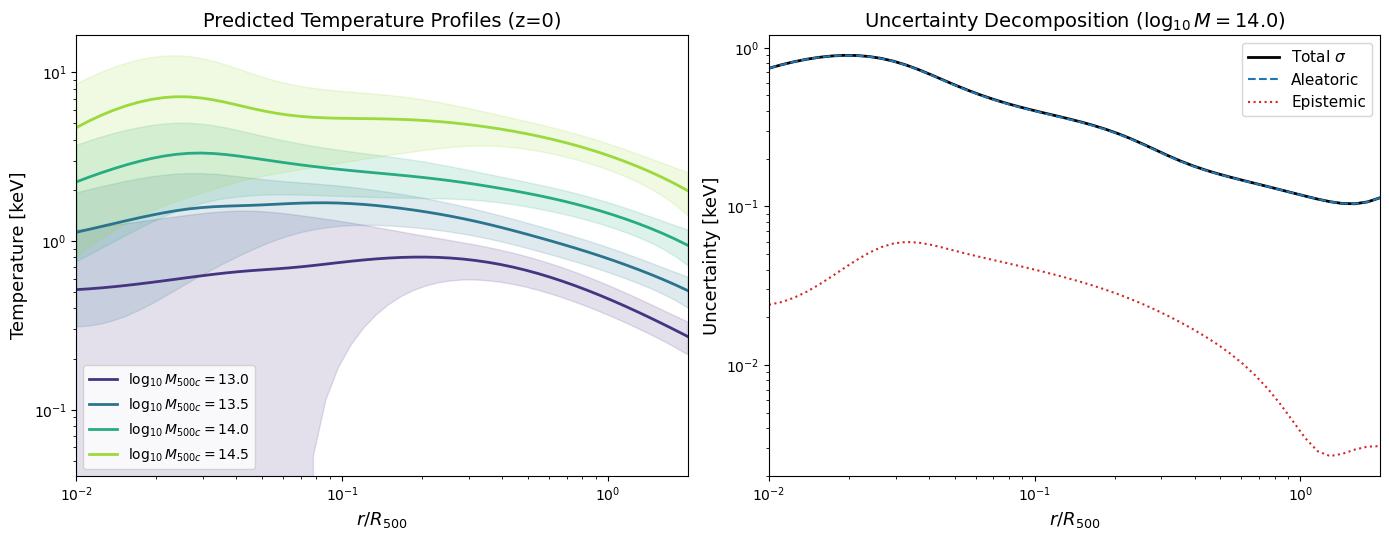

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(masses)))

# --- Panel 1: Temperature profiles ---
ax = axes[0]
for i, (lm, color) in enumerate(zip(log_masses, colors)):
    mu = pred_T.mean[i]
    std = pred_T.total_std[i]
    ax.plot(r_over_r500, mu, color=color, lw=2, label=f"$\\log_{{10}} M_{{500c}} = {lm:.1f}$")
    ax.fill_between(r_over_r500, mu - 2 * std, mu + 2 * std, alpha=0.15, color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$r / R_{500}$", fontsize=13)
ax.set_ylabel("Temperature [keV]", fontsize=13)
ax.set_title("Predicted Temperature Profiles (z=0)", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])

# --- Panel 2: Uncertainty decomposition ---
ax = axes[1]
i_ref = 2  # 10^14 M☉ halo
ax.plot(r_over_r500, pred_T.total_std[i_ref], 'k-', lw=2, label="Total $\\sigma$")
ax.plot(r_over_r500, pred_T.aleatoric_std[i_ref], 'C0--', lw=1.5, label="Aleatoric")
ax.plot(r_over_r500, pred_T.epistemic_std[i_ref], 'C3:', lw=1.5, label="Epistemic")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$r / R_{500}$", fontsize=13)
ax.set_ylabel("Uncertainty [keV]", fontsize=13)
ax.set_title(f"Uncertainty Decomposition ($\\log_{{10}} M = {log_masses[i_ref]:.1f}$)", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

## 7.5 Predict All Channels Simultaneously

The multi-channel mode returns all predicted fields at once:

In [7]:
# Request all available fields at once
all_fields = emu.available_fields()
print(f"Predicting fields: {all_fields}")

pred_all = emu.predict(
    theta=theta_fiducial,
    M=masses,
    r_bins=r_over_r500,
    field=all_fields,
    snapnum=90,
    n_samples=50,
)

print(f"\nOutput shape: {pred_all.mean.shape}")
print(f"  → (n_halo={len(masses)}, n_r={len(r_over_r500)}, n_fields={len(all_fields)})")

Predicting fields: ['gas_density', 'temperature', 'pressure', 'metallicity']

Output shape: (4, 50, 4)
  → (n_halo=4, n_r=50, n_fields=4)


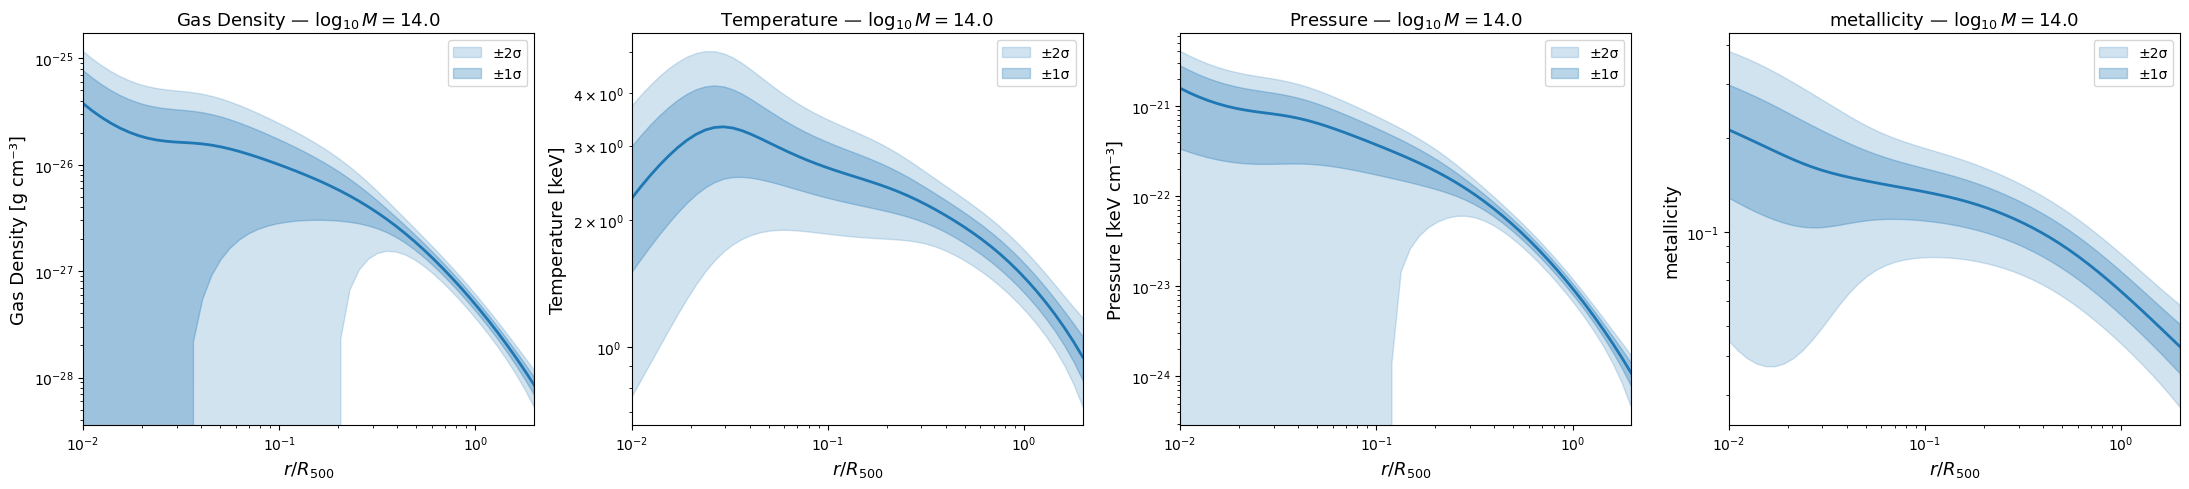

In [8]:
# Plot all channels for a single halo mass
field_labels = {
    'temperature': ('Temperature', 'keV'),
    'pressure': ('Pressure', 'keV cm⁻³'),
    'gas_density': ('Gas Density', 'g cm⁻³'),
}

i_halo = 2  # 10^14 M☉
n_fields = len(all_fields)
fig, axes = plt.subplots(1, n_fields, figsize=(5.5 * n_fields, 5))
if n_fields == 1:
    axes = [axes]

for k, (fname, ax) in enumerate(zip(all_fields, axes)):
    mu = pred_all.mean[i_halo, :, k]
    std = pred_all.total_std[i_halo, :, k]

    ax.plot(r_over_r500, mu, 'C0-', lw=2)
    ax.fill_between(r_over_r500, mu - 2 * std, mu + 2 * std, alpha=0.2, color='C0', label='±2σ')
    ax.fill_between(r_over_r500, mu - std, mu + std, alpha=0.3, color='C0', label='±1σ')

    label, units = field_labels.get(fname, (fname, ''))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('$r / R_{500}$', fontsize=13)
    ax.set_ylabel(f'{label} [{units}]' if units else label, fontsize=13)
    ax.set_title(f'{label} — $\\log_{{10}} M = {log_masses[i_halo]:.1f}$', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

## 7.6 Exploring Parameter Dependence

A key advantage of the emulator: we can rapidly explore how profiles change across the parameter space. Let's vary one feedback parameter while keeping others fixed.

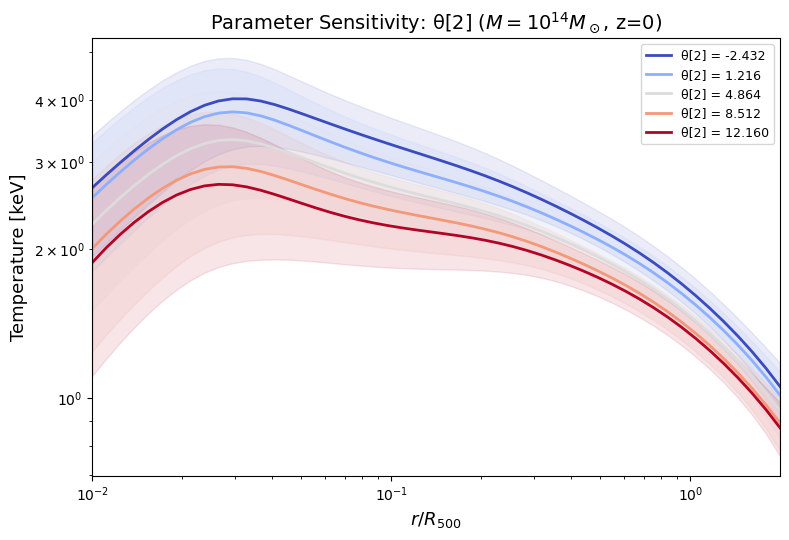

In [9]:
# Vary the first astrophysical parameter (index 2 in theta = Omega_m, sigma_8, ASN1, ...)
# We'll vary the 3rd parameter (ASN1 — SN feedback strength)
param_idx = 2  # 0-indexed within theta
param_values = np.linspace(
    theta_fiducial[param_idx] - 1.5 * abs(theta_fiducial[param_idx]),
    theta_fiducial[param_idx] + 1.5 * abs(theta_fiducial[param_idx]),
    5
)

M_single = np.array([1e14])  # single 10^14 M☉ halo

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(param_values)))

for j, (pval, color) in enumerate(zip(param_values, colors)):
    theta_var = theta_fiducial.copy()
    theta_var[param_idx] = pval

    pred_j = emu.predict(
        theta=theta_var,
        M=M_single,
        r_bins=r_over_r500,
        field="temperature",
        snapnum=90,
        n_samples=30,
    )

    ax.plot(r_over_r500, pred_j.mean[0], color=color, lw=2,
            label=f"θ[{param_idx}] = {pval:.3f}")
    ax.fill_between(r_over_r500,
                    pred_j.mean[0] - pred_j.total_std[0],
                    pred_j.mean[0] + pred_j.total_std[0],
                    alpha=0.1, color=color)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$r / R_{500}$', fontsize=13)
ax.set_ylabel('Temperature [keV]', fontsize=13)
ax.set_title(f'Parameter Sensitivity: θ[{param_idx}] ($M = 10^{{14}} M_\\odot$, z=0)', fontsize=14)
ax.legend(fontsize=9, loc='best')
ax.set_xlim(r_over_r500[0], r_over_r500[-1])
plt.tight_layout()
plt.show()

## 7.7 Multi-Redshift Predictions

If the model was trained on multiple snapshots, we can predict profiles at different redshifts:

Available snapshots: [90]
Redshift mapping:   {90: 0.0, 74: 0.5, 60: 1.0, 44: 2.0}


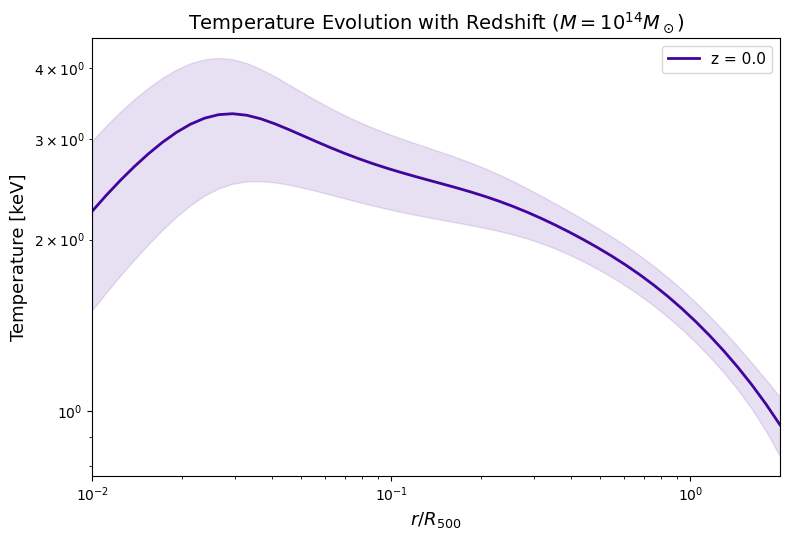

In [10]:
print(f"Available snapshots: {emu.snapnums}")
print(f"Redshift mapping:   {emu.redshift_by_snap}")

M_demo = np.array([1e14])

fig, ax = plt.subplots(figsize=(8, 5.5))
colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(emu.snapnums)))

for snap, color in zip(emu.snapnums, colors_z):
    z_val = emu.redshift_by_snap.get(snap, None)
    label = f"z = {z_val:.1f}" if z_val is not None else f"snap {snap}"

    try:
        pred_z = emu.predict(
            theta=theta_fiducial,
            M=M_demo,
            r_bins=r_over_r500,
            field="temperature",
            snapnum=snap,
            n_samples=30,
        )
        ax.plot(r_over_r500, pred_z.mean[0], color=color, lw=2, label=label)
        ax.fill_between(r_over_r500,
                        pred_z.mean[0] - pred_z.total_std[0],
                        pred_z.mean[0] + pred_z.total_std[0],
                        alpha=0.12, color=color)
    except Exception as e:
        print(f"  Skipping snap {snap}: {e}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$r / R_{500}$', fontsize=13)
ax.set_ylabel('Temperature [keV]', fontsize=13)
ax.set_title('Temperature Evolution with Redshift ($M = 10^{14} M_\\odot$)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])
plt.tight_layout()
plt.show()

## 7.8 Log-Space Uncertainty

For channels modeled in $\log_{10}$ space, the model also returns log-space predictions. These often give better-calibrated, symmetric uncertainties:

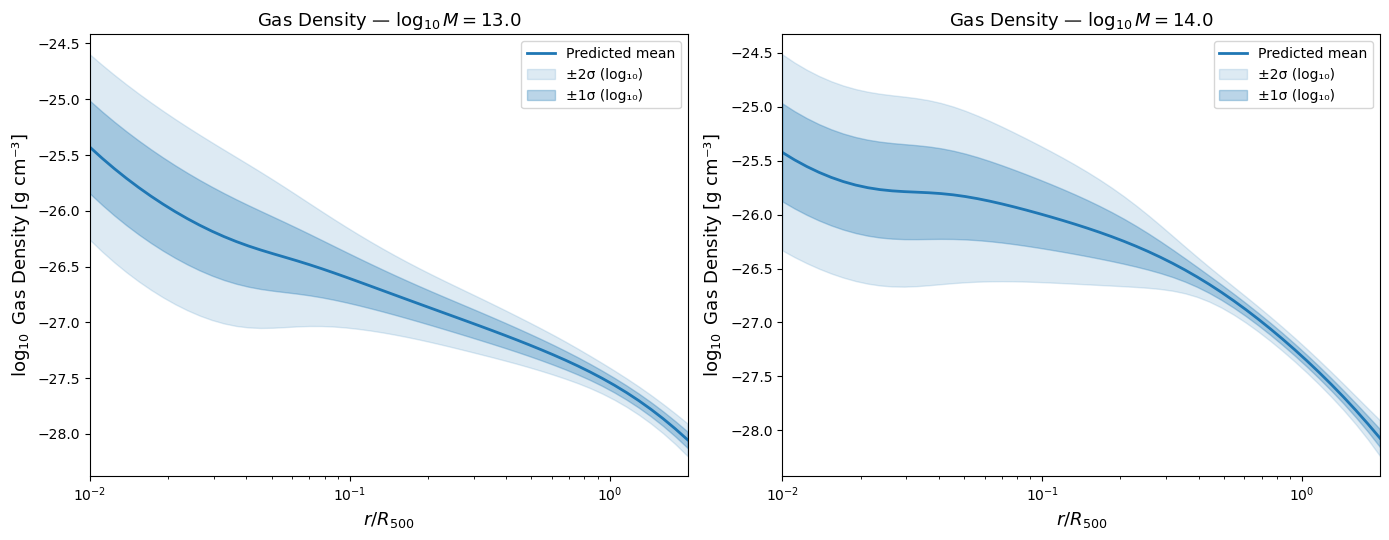

In [11]:
pred_rho = emu.predict(
    theta=theta_fiducial,
    M=np.array([1e13, 1e14]),
    r_bins=r_over_r500,
    field="gas_density",
    snapnum=90,
    n_samples=50,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i_h, (lm, ax) in enumerate(zip([13.0, 14.0], axes)):
    # Log-space: symmetric bands
    if pred_rho.mean_log10 is not None:
        mu_log = pred_rho.mean_log10[i_h]
        std_log = pred_rho.std_log10[i_h]
        ax.plot(r_over_r500, mu_log, 'C0-', lw=2, label='Predicted mean')
        ax.fill_between(r_over_r500, mu_log - 2 * std_log, mu_log + 2 * std_log,
                        alpha=0.15, color='C0', label='±2σ (log₁₀)')
        ax.fill_between(r_over_r500, mu_log - std_log, mu_log + std_log,
                        alpha=0.3, color='C0', label='±1σ (log₁₀)')
        ax.set_ylabel('$\\log_{10}$ Gas Density [g cm⁻³]', fontsize=13)
    else:
        ax.plot(r_over_r500, pred_rho.mean[i_h], 'C0-', lw=2)
        ax.set_yscale('log')
        ax.set_ylabel('Gas Density [g cm⁻³]', fontsize=13)

    ax.set_xscale('log')
    ax.set_xlabel('$r / R_{500}$', fontsize=13)
    ax.set_title(f'Gas Density — $\\log_{{10}} M = {lm:.1f}$', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

---
# 8. Diagnostics

The `anp_emulator.diagnostics` module provides tools for evaluating emulator quality.

## 8.1 Coverage Curves

A coverage curve checks whether the predicted uncertainties are **calibrated**: if we claim 90% confidence intervals, do they contain the true value 90% of the time?

$$\text{Empirical coverage}(p) = \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}\!\left[|y_i - \hat{\mu}_i| \leq z_{(1+p)/2} \cdot \hat{\sigma}_i\right]$$

A perfectly calibrated model gives empirical coverage = nominal coverage (the diagonal).

In [12]:
from anp_emulator import coverage_curve, plot_coverage_curve

## 8.2 Residual Analysis

The residual-vs-radius summary shows systematic bias as a function of radius:

In [13]:
from anp_emulator import rmse_by_field, residual_radius_summary, plot_residual_vs_radius

## 8.3 PIT Histogram

The **Probability Integral Transform (PIT)** checks if predicted CDFs are uniform under the true data distribution:

$$\text{PIT}_i = \Phi\!\left(\frac{y_i - \hat{\mu}_i}{\hat{\sigma}_i}\right)$$

A well-calibrated model produces a uniform PIT histogram. Deviations indicate:
- **U-shaped**: under-dispersed (uncertainties too small)
- **Inverse-U**: over-dispersed (uncertainties too large)
- **Skewed**: systematic bias

In [14]:
from anp_emulator import pit_values

## 8.4 Quick Diagnostics Example

To compute full diagnostics you need validation/test data. Here's the pattern for how you'd use it with held-out simulation data:

In [15]:
# Pseudocode for full diagnostic pipeline (requires test data)
#
# from train_anp_emulator import build_tasks, split_tasks
# from types import SimpleNamespace
#
# args = SimpleNamespace(**dict(emu.args))
# all_families = build_tasks(args)
# train_fam, val_fam, test_fam = split_tasks(
#     all_families,
#     train_frac=args.train_frac,
#     val_frac=args.val_frac,
#     seed=args.seed,
# )
#
# # For each test family, predict and collect (y_true, y_pred, y_std)
# y_true_all, y_pred_all, y_std_all = [], [], []
# for fam in test_fam:
#     for task in fam.snapshots:
#         theta_test = task.x[0, 0, 2:37]  # extract theta from first halo
#         m500c_test = 10.0 ** task.x[:, 0, 0]  # un-log the masses
#         r_bins_test = 10.0 ** task.x[0, :, 1]  # un-log the radii (r/R500)
#
#         pred = emu.predict(
#             theta=theta_test, M=m500c_test,
#             r_bins=r_bins_test, field=emu.available_fields(),
#             snapnum=task.snapnum, n_samples=50,
#         )
#
#         y_true_all.append(task.y)  # true log-space values
#         y_pred_all.append(pred.mean_log10)  # predicted in log space
#         y_std_all.append(pred.std_log10)
#
# y_true = np.concatenate(y_true_all, axis=0)
# y_pred = np.concatenate(y_pred_all, axis=0)
# y_std  = np.concatenate(y_std_all, axis=0)
#
# # RMSE per field
# print(rmse_by_field(y_true, y_pred, emu.available_fields()))
#
# # Coverage curve
# cov = coverage_curve(y_true, y_pred, y_std, emu.available_fields())
# plot_coverage_curve(cov)
#
# # PIT histogram
# pit = pit_values(y_true, y_pred, y_std)
# plt.hist(pit.ravel(), bins=50, density=True)
# plt.axhline(1.0, color='k', ls='--')
# plt.xlabel('PIT value')
# plt.ylabel('Density')
# plt.title('PIT Histogram')
# plt.show()

print("See the diagnostic modules for the full API:")
print("  from anp_emulator import build_diagnostics_report")
print("  report = build_diagnostics_report(y_true, prediction, r_bins)")

See the diagnostic modules for the full API:
  from anp_emulator import build_diagnostics_report
  report = build_diagnostics_report(y_true, prediction, r_bins)


---
# 9. Training Your Own Model

Training is done via the command-line script `train_anp_emulator.py`. Here's the typical workflow:

## 9.1 Minimal Training Command

```bash
python train_anp_emulator.py \
    --profiles-base /path/to/profiles/ \
    --param-csv /path/to/param_df.csv \
    --target-name all_profiles \
    --all-profiles-subset temperature pressure gas_density \
    --suite IllustrisTNG --sim-set SB35 \
    --snapnum 90 \
    --epochs 500 --patience 120 \
    --d-model 192 --d-latent 96 \
    --dec-hidden 384 --dec-layers 4 \
    --dropout 0.25 --weight-decay 1e-3 \
    --kl-warmup-epochs 80 \
    --mean-epochs 100 --mean-loss huber
```

## 9.2 Key Hyperparameters

| Parameter | Typical Value | Description |
|-----------|---------------|-------------|
| `--d-model` | 192 | Transformer hidden dimension |
| `--d-latent` | 96 | Latent variable dimension |
| `--dec-hidden` | 384 | Decoder MLP width |
| `--dec-layers` | 4 | Decoder MLP depth |
| `--dropout` | 0.25 | Dropout rate throughout |
| `--kl-warmup-epochs` | 80–120 | Epochs to anneal β from 0 → 1 |
| `--patience` | 80–120 | Early stopping patience |
| `--decoder-likelihood` | gaussian/student_t | Output distribution family |
| `--context-dropout-rate` | 0.3 | Fraction of context points dropped |
| `--mean-loss` | huber | Mean model loss (huber = robust to outliers) |

## 9.3 Multi-Redshift Training

```bash
python train_anp_emulator.py \
    ... \
    --snapnums 90 74 60 44 \
    --snapshot-redshifts "90:0.0,74:0.5,60:1.0,44:2.0" \
    --per-snapshot-mean \
    --snapshot-balanced-loss \
    --time-feature-scale 1.0
```

## 9.4 For HPC (Slurm)

See the `run_train_anp_emulator_*.sh` scripts for ready-made SLURM job scripts that handle GPU allocation and environment setup.

---
# 10. Summary

## What we covered

| Section | Key Takeaway |
|---------|--------------|
| Motivation | CAMELS profiles are expensive; emulators enable rapid parameter exploration |
| Math | ANPs use ELBO training with dual encoder paths (latent + deterministic) |
| Data | Inputs = (log M, log r, θ₃₅); outputs = profile channels in log₁₀ space |
| Architecture | Fourier radius embedding + transformer encoders + FiLM-conditioned decoder |
| Training | Two-stage (mean model → ANP on residuals) with extensive regularization |
| API | 3 lines: `from_run_dir` → `predict` → access `mean`, `total_std`, etc. |
| Diagnostics | Coverage curves, PIT histograms, RMSE, residual-vs-radius analysis |

## The API at a glance

```python
from anp_emulator import Emulator

emu = Emulator.from_run_dir("anp_training_runs/my_run")

result = emu.predict(
    theta=my_params,         # (35,) feedback + cosmo parameters
    M=halo_masses,           # (n_halo,) solar masses 
    r_bins=r_over_r500,      # (n_r,) or (n_halo, n_r) radial bins
    field="temperature",     # str or list of field names
    snapnum=90,              # snapshot number (optional)
    n_samples=50,            # number of latent draws
)

# result.mean, result.total_std, result.aleatoric_std, result.epistemic_std
# result.mean_log10, result.std_log10  (for log-space channels)
```

## References

- Garnelo et al. (2018) — *Neural Processes* ([arXiv:1807.01622](https://arxiv.org/abs/1807.01622))
- Kim et al. (2019) — *Attentive Neural Processes* ([arXiv:1901.05761](https://arxiv.org/abs/1901.05761))
- CAMELS Project — [camels.readthedocs.io](https://camels.readthedocs.io/)
- Villaescusa-Navarro et al. (2021) — *The CAMELS Project* ([arXiv:2010.00619](https://arxiv.org/abs/2010.00619))
- Kendall & Gal (2017) — *What Uncertainties Do We Need in Bayesian Deep Learning?* ([arXiv:1703.04977](https://arxiv.org/abs/1703.04977))
- Seitzer et al. (2022) — *On the Pitfalls of Heteroscedastic Uncertainty Estimation* (Beta-NLL)

In [ ]:
print("Tutorial complete! 🎉")
print(f"\nQuick reference:")
print(f"  Fields available:  {emu.available_fields()}")
print(f"  θ dimension:       {emu.theta_dim}")
print(f"  Snapshots:         {emu.snapnums}")
print(f"  Checkpoint:        {emu.checkpoint_path}")